In [55]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# for text xlassification project 
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# to store all data in vector and text cleaning process
# English stop words

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

In [56]:
df= pd.read_csv('movie_review.csv')

In [57]:
#clean text
def clean_text(text):
    #to remove all unwanted HTML tags in review
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'[^a-zA-Z\s]','',text).lower()
    return text

In [58]:
df['review'] = df['review'].apply(clean_text)

In [59]:
X = df['review']
Y = df['sentiment']

In [60]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size= 0.2, random_state=42, 
)

In [61]:
ignore_wordss = {'no', 'not'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS) - ignore_wordss)

In [62]:
tfidf = TfidfVectorizer(
    stop_words=custom_stop_words,
    ngram_range=(1, 2)
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [67]:
model = MultinomialNB(alpha=0.1)  # default is 1
model.fit(X_train_tfidf, Y_train)

Y_pred = model.predict(X_test_tfidf)

In [68]:

cr = classification_report(Y_test,Y_pred)
cm = confusion_matrix(Y_test,Y_pred)
print(cm)

[[4438  523]
 [ 614 4425]]


In [69]:
print(cr)

              precision    recall  f1-score   support

    negative       0.88      0.89      0.89      4961
    positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



<Axes: >

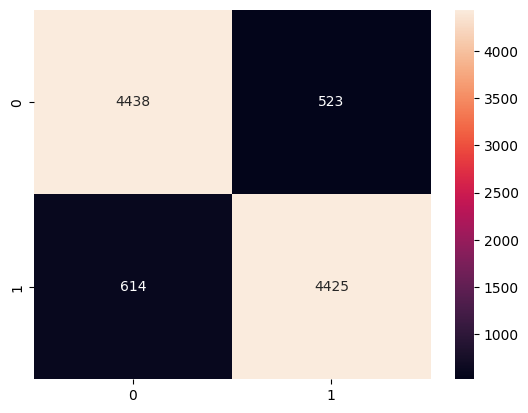

In [70]:
sns.heatmap(cm, annot=True, fmt='.0f')